In [13]:
%matplotlib inline

ndevices = 30
import os
os.environ["XLA_FLAGS"] = f"--xla_force_host_platform_device_count={ndevices}"
os.environ["OMP_NUM_THREADS"] = f"{ndevices}"
os.environ["MKL_NUM_THREADS"] = f"{ndevices}"
os.environ["NUMEXPR_NUM_THREADS"] = f"{ndevices}"
os.environ["OPENBLAS_NUM_THREADS"] = f"{ndevices}"
os.environ["VECLIB_MAXIMUM_THREADS"] = f"{ndevices}"
os.environ["NUMBA_NUM_THREADS"] = f"{ndevices}"
os.environ["JAX_TRACEBACK_FILTERING"] = "off"

import multiprocessing
import pandas as pd
import sys
import glob
from functools import partial
from astropy.io import fits, ascii
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
plt.style.use('style.mplstyle')
from astropy import units as u
from astropy.table import Table
import astropy.constants as const
from astropy.coordinates import SkyCoord, concatenate
from astropy import table
from astropy.cosmology import FlatLambdaCDM, Flatw0waCDM, w0waCDM, z_at_value, wCDM, LambdaCDM
import scipy.stats as st
from scipy.optimize import minimize
from scipy.signal import fftconvolve
import warnings
import h5py
import emcee
import corner
from scipy.stats import norm
import time


### Read the light curve fitting and quasar parameters

In [2]:
bands = ['u', 'g', 'r', 'i', 'z']#, 'y']

def read_quasars_from_hdf5(file_path):
    quasar_list = []
    with h5py.File(file_path, "r") as hdf:
        for group_name in hdf.keys():
            group = hdf[group_name]
            quasar = {"object_id": group_name}
            for key, value in group.attrs.items():
                quasar[key] = value
            for sub_group_name in group.keys():
                sub_group = group[sub_group_name]
                quasar[sub_group_name] = {sub_key: sub_group[sub_key][...] for sub_key in sub_group.keys()}
            quasar_list.append(quasar)
    return quasar_list


quasar_list = read_quasars_from_hdf5("data/may4_objs_tauwavelength.h5")
print("Number of quasars loaded:", len(quasar_list))

hdul = fits.open('data/dr16q_prop_May01_2024.fits')
fits_data = hdul[1].data  # Assuming the data is in the first extension    
fits_data_2 = hdul[2].data  # Assuming the data is in the first extension    

def populate_sdss_fields(d):
    i = np.argwhere(d['sdss_name'] == fits_data['SDSS_NAME']).flatten()
    if len(i) == 0:
        print(f"Warning: {d['sdss_name']} not found in SDSS data")
        return d
    i = i[0]
    if np.any(fits_data_2['PSFFLUX'][i,:] <= 0):
        return d
    d['log_mbh'] = fits_data['LOGMBH'][i]
    d['log_mbh_err'] = fits_data['LOGMBH_ERR'][i]
    d['log_ledd_ratio'] = fits_data['LOGLEDD_RATIO'][i]
    d['log_ledd_ratio_err'] = fits_data['LOGLEDD_RATIO_ERR'][i]
    d['ebv'] = fits_data['EBV'][i]
    d['M_i'] = fits_data_2['M_I'][i]
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        d['apparent_mag_z'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,4]) + 22.5
        d['apparent_mag_i'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,3]) + 22.5
        d['apparent_mag_r'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,2]) + 22.5
        d['apparent_mag_g'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,1]) + 22.5
        d['apparent_mag_u'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,0]) + 22.5
        d['apparent_mag_z_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,4])/fits_data_2['PSFFLUX'][i,4]
        d['apparent_mag_i_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,3])/fits_data_2['PSFFLUX'][i,3]
        d['apparent_mag_r_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,2])/fits_data_2['PSFFLUX'][i,2]
        d['apparent_mag_g_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,1])/fits_data_2['PSFFLUX'][i,1]
        d['apparent_mag_u_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,0])/fits_data_2['PSFFLUX'][i,0]
        d['color'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i, 0] / fits_data_2['PSFFLUX'][i, 3])
    if any(issubclass(warning.category, RuntimeWarning) for warning in w):
        print(f"RuntimeWarning occurred for {d['sdss_name']}")
        print(fits_data_2['PSFFLUX'][i,:])
        print(w)
    return d

def calc_lam_RF(d):
    lam_pivot = {
        'V': 5477,  # Johnson (no direct SDSS equivalent)
        'B': 4353,  # Johnson (no direct SDSS equivalent)
        'R': 6580,  # SDSS r-band
        'g': 4770,  # SDSS g-band
        'r': 6231,  # SDSS r-band
        'i': 7625,  # SDSS i-band
        'z': 9134,  # SDSS z-band
        'u': 3543,  # SDSS u-band
        'y': 9633,  # PS1 y-band
        'TESS': 7865,  # TESS broadband filter
        'kepler': 6420,  # Kepler broadband filter
        '5100 AA': 5100  # Reference wavelength
    }
    # Compute rest-frame wavelength
    lam_pivots = lam_pivot['i']
    lam_RF = lam_pivots / (1 + d['z'])
    d['log_lambda_RF'] = np.log10(lam_RF)
    return d

def split_field_by_band_nm1(q, keys):
    clean_bands = q['clean_bands'][1:]
    for key in keys:
        try:
            for i, b in enumerate(clean_bands):
                q[f'{key}_{b}'] = q[key][i]
            for b in list(set(bands) - set(clean_bands)):
                q[f'{key}_{b}'] = -1
        except:
            print(f"{key=}, {b=}, {clean_bands=}, {i=}, {q[key].shape=}")

def split_field_by_band(q, keys):
    clean_bands = q['clean_bands']
    for key in keys:
        try:
            for i, b in enumerate(clean_bands):
                q[f'{key}_{b}'] = q[key][i]
            for b in list(set(bands) - set(clean_bands)):
                q[f'{key}_{b}'] = -1
        except:
            print(f"{key=}, {b=}, {clean_bands=}, {i=}, {q[key].shape=}")

for q in quasar_list:
    for b in q['magerrs'].keys():
        if len(q['magerrs'][b]) == 0:
            continue
        q[f'magerrs_mean_{b}'] = np.nanmean(q['magerrs'][b])
    split_field_by_band(q, ['log_sigma_band', 'log_sigma_band_err', 'log_jitter'])
    split_field_by_band_nm1(q, ['lag', 'lag_err', 'log_lag_blr', 'log_lag_blr_err'])

    populate_sdss_fields(q)
    calc_lam_RF(q)
    q['delta_time'] = q['times']['r'].max() - q['times']['r'].min()

df = pd.DataFrame(quasar_list)
#df = df.set_index('object_id')
#df = df.drop(columns=['log_jitter', 'magerrs_mean', 'log_sigma_band', 'log_sigma_band_err', 'clean_bands'])
df = df.drop(columns=['mags', 'times', 'magerrs'])

df_all = df.copy()

# Remove infinite values from numeric columns
columns_with_nans = df.columns[df.isna().any()].tolist()
print("Columns with NaNs:", columns_with_nans)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].where(~np.isinf(df[numeric_cols]), np.nan)
df = df.dropna()

for i, band in enumerate(bands):
    df = df[(df[f'log_sigma_band_{band}'] == -1) | ((10**df[f'log_sigma_band_{band}']) > 1.*np.sqrt(df[f'magerrs_mean_{band}']**2 + (10**df[f'log_jitter_{band}'])**2))]

df_original = df.copy()

print("Final number of quasars:", len(df))
df.head()
#df[['object_id']][:100].to_csv('data/df_quasars_filtered_apr27.csv', index=False)

Number of quasars loaded: 524
Columns with NaNs: []
Final number of quasars: 139


,object_id,beta,beta_err,clean_bands,dec,delta,delta_err,i,lag,lag_err,...,apparent_mag_g,apparent_mag_u,apparent_mag_z_err,apparent_mag_i_err,apparent_mag_r_err,apparent_mag_g_err,apparent_mag_u_err,color,log_lambda_RF,delta_time
7,1388428,-0.167858,0.094538,"[u, g, r, i, z]",0.380098,0.384165,0.064483,7,"[3.1466957676510527, 5.101065170053106, -22.33...","[5.007422574556907, 10.37837200009737, 18.9101...",...,19.419571,19.443937,0.037060,0.021654,0.020916,0.024838,0.030142,0.182863,3.753382,8068.003247
8,1388445,-0.202337,0.059923,"[u, g, r, i, z]",1.156838,0.391824,0.049768,8,"[2.354904550274732, -3.088051730039816, 0.5433...","[2.750056157859034, 3.501645304539101, 2.94791...",...,18.455492,18.639133,0.030172,0.014117,0.011099,0.023494,0.020719,0.233411,3.591278,7452.752323
14,1388513,-0.012612,0.062360,"[u, g, r, i, z]",-0.291992,0.228747,0.053452,14,"[-12.11066433845921, -4.777340064089218, -19.1...","[5.819434553021869, 5.201703634714803, 6.88332...",...,19.370337,19.480885,0.047305,0.025051,0.025908,0.020434,0.025819,0.398161,3.531204,8369.068557
16,1388637,-0.296226,0.077485,"[u, g, r, i, z]",-0.934498,0.344327,0.064823,16,"[14.575781222307478, 8.179698567101394, 0.6962...","[6.283267355212727, 6.431304873552361, 9.34089...",...,19.198532,19.333923,0.034857,0.023888,0.025172,0.029012,0.028076,0.535627,3.448151,8420.993226
19,1388651,0.037756,0.034601,"[u, g, r, i, z]",0.181636,0.361722,0.042317,19,"[13.976127007092405, 13.092531639954572, 7.566...","[6.879365827721187, 4.271588429073683, 1.65517...",...,19.785812,19.729168,0.066887,0.019918,0.020931,0.016139,0.031340,0.294734,3.550500,8369.068569


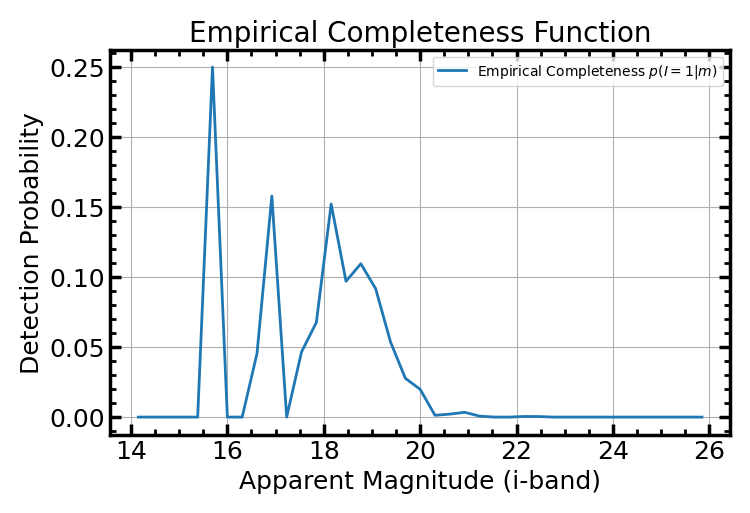

In [3]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Load the magnitude true dist data
file_path = "stacked_sampled_apparent_magnitudes.h5"

with h5py.File(file_path, "r") as f:
    mags_true = f["stacked_apparent_magnitudes"][:]

mags_obs = df['apparent_mag_i'].values

# Clean both datasets
mags_true = mags_true[np.isfinite(mags_true)]
mags_obs = mags_obs[np.isfinite(mags_obs)]

# Histogram bins
bin_edges = np.linspace(14, 26, 40)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
dm = np.diff(bin_edges)[0]

# Histogram both samples
hist_true, _ = np.histogram(mags_true, bins=bin_edges)
hist_obs, _ = np.histogram(mags_obs, bins=bin_edges)

# Avoid division by zero
mask = hist_true > 0
completeness_ratio = np.zeros_like(hist_true, dtype=float)
completeness_ratio[mask] = hist_obs[mask] / hist_true[mask]

# Smooth or regularize if needed
completeness_ratio = np.clip(completeness_ratio, 0, 1)

# Interpolation
p_detect_interp = interp1d(
    bin_centers,
    completeness_ratio,
    kind='linear',
    bounds_error=False,
    fill_value=(1.0, 0.0)
)

# Plot for inspection
plt.figure(figsize=(8, 5))
plt.plot(bin_centers, completeness_ratio, label="Empirical Completeness $p(I=1|m)$", lw=2)
plt.xlabel("Apparent Magnitude (i-band)")
plt.ylabel("Detection Probability")
plt.title("Empirical Completeness Function")
plt.grid(True)
plt.legend(fontsize=10)
plt.show()


In [4]:
def drop_faintest_bin(df, z_col='z', mag_col='apparent_mag_i', z_bins_width=0.1, mag_margin=0.5):
    """
    Drop quasars within mag_margin magnitude of the faintest quasar in each redshift bin.

    Parameters:
        df (pd.DataFrame): Input dataframe containing redshifts and apparent magnitudes.
        z_col (str): Column name for redshift.
        mag_col (str): Column name for apparent magnitude.
        z_bins_width (float): Width of each redshift bin.
        mag_margin (float): Magnitude range to drop above the faintest object.

    Returns:
        pd.DataFrame: Filtered dataframe.
    """
    df = df.copy().reset_index(drop=True)

    # Create redshift bins
    z_min, z_max = df[z_col].min(), df[z_col].max()
    z_bins = np.arange(z_min, z_max + z_bins_width, z_bins_width)

    # Assign bin labels
    df['z_bin'] = pd.cut(df[z_col], bins=z_bins, include_lowest=True)

    # Container for indices to drop
    indices_to_drop = []

    # Iterate over each redshift bin
    for bin_interval, group in df.groupby('z_bin'):
        if len(group) == 0:
            continue
        faintest_mag = group[mag_col].max()  # Faintest magnitude (largest value)
        
        # Identify objects within mag_margin from the faintest magnitude
        drop_condition = group[mag_col] >= (faintest_mag - mag_margin)
        indices_to_drop.extend(group[drop_condition].index.tolist())

    # Drop identified indices
    filtered_df = df.drop(indices_to_drop).reset_index(drop=True)

    # Drop auxiliary bin column
    filtered_df = filtered_df.drop(columns='z_bin')

    return filtered_df

# Data cuts

In [5]:
#d = df.iloc[df['appare
# nt_mag_i_err'].argmax()]
df = df_original.copy()

# data cuts
df = df[df['log_sigma_RF'] < 0]
df = df[df['log_tau_RF'] > 1.5]
df = df[df['log_lbol'] > 44]
df = df[df['log_mbh'] > 1]
df = df[df['apparent_mag_i'] < 20]
df = df[df['M_i'] < -20]
df = df[df['ebv'] < 0.05]
#df = df[df['z'] > 1.]
#df = df[df['beta'] > -1]
#df = df[df['beta'] < 0]

#df = drop_faintest_bin(df, z_col='z', mag_col='apparent_mag_i', z_bins_width=0.1, mag_margin=0.5)

# df = df[np.abs(df['apparent_mag_i_err'] / df['apparent_mag_i']) < 0.01]
# df = df[np.abs(df['log_sigma_RF_err'] / df['log_sigma_RF']) < 0.3]
# df = df[np.abs(df['log_tau_RF_err'] / df['log_tau_RF']) < 0.2]

df.reset_index(drop=True)
#df = df_original.copy()
print(len(df))

#df[np.abs(df['log_tau_RF_err']/df['log_tau_RF']) < 0.1]

123


### Load the SNIa data

In [6]:
url = 'https://github.com/PantheonPlusSH0ES/DataRelease/blob/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat?raw=true'
df_pantheon = pd.read_csv(url, delim_whitespace=True)
df_pantheon.keys()

/tmp/ipykernel_3887/2347323853.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_pantheon = pd.read_csv(url, delim_whitespace=True)


Index(['CID', 'IDSURVEY', 'zHD', 'zHDERR', 'zCMB', 'zCMBERR', 'zHEL',
       'zHELERR', 'm_b_corr', 'm_b_corr_err_DIAG', 'MU_SH0ES',
       'MU_SH0ES_ERR_DIAG', 'CEPH_DIST', 'IS_CALIBRATOR', 'USED_IN_SH0ES_HF',
       'c', 'cERR', 'x1', 'x1ERR', 'mB', 'mBERR', 'x0', 'x0ERR', 'COV_x1_c',
       'COV_x1_x0', 'COV_c_x0', 'RA', 'DEC', 'HOST_RA', 'HOST_DEC',
       'HOST_ANGSEP', 'VPEC', 'VPECERR', 'MWEBV', 'HOST_LOGMASS',
       'HOST_LOGMASS_ERR', 'PKMJD', 'PKMJDERR', 'NDOF', 'FITCHI2', 'FITPROB',
       'm_b_corr_err_RAW', 'm_b_corr_err_VPEC', 'biasCor_m_b',
       'biasCorErr_m_b', 'biasCor_m_b_COVSCALE', 'biasCor_m_b_COVADD'],
      dtype='object')

In [7]:
import requests

# Define the URLs for the data and covariance files
data_file_url = "https://github.com/PantheonPlusSH0ES/DataRelease/blob/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat?raw=true"
covmat_file_url = "https://github.com/PantheonPlusSH0ES/DataRelease/blob/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES_STAT+SYS.cov?raw=true"

def download_file(url):
    """Download a file from a given URL and return its content."""
    response = requests.get(url)
    response.raise_for_status()  # Raise an error for bad status codes
    return response.text

# Download the data and covariance files
data_file_content = download_file(data_file_url)
covmat_file_content = download_file(covmat_file_url)

def build_covariance(data_content, covmat_content):
    """Build the covariance matrix for the data using the downloaded content."""
    print("Building covariance matrix from downloaded content")

    # Parse the data content
    data_lines = data_content.splitlines()
    zCMB = [float(line.split()[1]) for line in data_lines[1:]]  # Assuming zCMB is in the second column
    ww = [True] * len(zCMB)  # Placeholder for weights
    origlen = len(zCMB)

    # Parse the covariance content
    cov_lines = covmat_content.splitlines()
    n = len(zCMB)
    C = np.zeros((n, n))
    ii = -1
    jj = -1
    for i in range(origlen):
        jj = -1
        if ww[i]:
            ii += 1
        for j in range(origlen):
            if ww[j]:
                jj += 1
            val = float(cov_lines[i * origlen + j])
            if ww[i] and ww[j]:
                C[ii, jj] = val

    print("Covariance matrix built successfully")
    return C

# Build the covariance matrix
covariance_matrix = build_covariance(data_file_content, covmat_file_content)
covariance_matrix

Building covariance matrix from downloaded content
Covariance matrix built successfully


array([[ 1.701000e+03,  3.177108e-02,  5.754430e-03, ...,  2.088400e-04,
         2.945500e-04, -8.595000e-05],
       [-2.701100e-04,  5.754430e-03,  3.456656e-02, ..., -2.746800e-04,
        -2.863200e-04, -2.456300e-04],
       [-2.363400e-04,  3.100600e-04,  6.595500e-04, ..., -4.070400e-04,
         1.936450e-03,  3.214810e-03],
       ...,
       [ 7.426700e-04,  2.945500e-04, -2.863200e-04, ...,  2.093270e-03,
         4.157373e-02,  4.902260e-03],
       [ 5.887030e-03, -8.595000e-05, -2.456300e-04, ...,  1.096370e-03,
         4.902260e-03,  6.742823e-02],
       [ 8.751110e-03, -2.701100e-04, -2.363400e-04, ...,  7.426700e-04,
         5.887030e-03,  8.751110e-03]], shape=(1701, 1701))

In [7]:

# --- Constants ---
z_pivot = df['z'].median()
sigma_pivot = -0.5
tau_pivot = 3

# --- Model Functions ---

def M_model_single(M0, alpha, delta, log_sigma_RF, log_tau_RF):
    """Variability-luminosity relation for one AGN."""
    return M0 + alpha * (log_sigma_RF - sigma_pivot) + delta * (log_tau_RF - tau_pivot)

def K_corr(z, alpha_nu=-0.5):
    """Simple K-correction."""
    return -2.5 * (1 + alpha_nu) * np.log10(1 + z)

# --- Build Empirical Completeness Function ---
mag_eval = np.linspace(14, 26, 500)
dm = mag_eval[1] - mag_eval[0]
p_detect = p_detect_interp(mag_eval)

# --- Priors ---

priors = {
    "alpha": (0, 5),
    "delta": (-2, 6),
    "M0": (-30, -10),
    "log_f": (-2, 1),
    "H0": (50, 80),
    "Om0": (0.1, 0.8),
}
labels = list(priors.keys())

# --- Log-likelihood ---

def log_likelihood(theta):
    alpha, delta, M0, log_f, H0, Om0 = theta

    # Prior bounds check
    for i, (key, val) in enumerate(priors.items()):
        if not (val[0] < theta[i] < val[1]):
            return -np.inf

    # Cosmology model
    cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)

    # AGN data vectors
    z = df['z'].values
    m_obs = df['apparent_mag_i'].values
    m_err = df['apparent_mag_i_err'].values
    log_sigma = df['log_sigma_RF'].values
    log_tau = df['log_tau_RF'].values
    log_sigma_err = df['log_sigma_RF_err'].values
    log_tau_err = df['log_tau_RF_err'].values

    # Cosmology predictions
    mu_cosmo = cosmo.distmod(z).value
    Kcorr = K_corr(z)
    M_pred = M0 + alpha * (log_sigma - sigma_pivot) + delta * (log_tau - tau_pivot)
    mu_pred = m_obs - M_pred - Kcorr

    # AGN uncertainty
    mu_err = np.sqrt(
        m_err**2 +
        (alpha * log_sigma_err)**2 +
        (delta * log_tau_err)**2 +
        (0.05 * Kcorr)**2 +
        (0.055 * z)**2 +
        np.exp(2 * log_f)
    )

    # Residuals
    dmu = mu_pred - mu_cosmo
    ll_agn = np.sum(norm.logpdf(dmu, scale=mu_err))

    # --- Selection Correction ---

    m_model = M_pred + mu_cosmo + Kcorr
    integrals = np.zeros(len(df))
    unique_errors = np.round(mu_err, 4)
    unique_vals = np.unique(unique_errors)

    for sigma in unique_vals:
        mask = (np.abs(mu_err - sigma) < 1e-6)
        if np.sum(mask) == 0:
            continue

        kernel = norm.pdf(mag_eval, loc=0.0, scale=sigma)
        conv = fftconvolve(p_detect, kernel, mode="same") * dm
        integrals[mask] = np.interp(m_model[mask], mag_eval, conv)

    norm_correction = np.sum(np.log(integrals + 1e-20))  # avoid log(0)

    # --- SNIa likelihood ---
    mu_snia = cosmo.distmod(df_pantheon['zHD']).value
    dmu_snia = df_pantheon['MU_SH0ES'] - mu_snia
    ll_snia = np.sum(norm.logpdf(dmu_snia, scale=df_pantheon['MU_SH0ES_ERR_DIAG']))
    #ll_snia = -0.5 * np.dot(dmu_snia, np.linalg.solve(covariance_matrix, dmu_snia)) + np.log(1/(2*np.pi * np.sqrt(np.linalg.det(covariance_matrix)))) # Slow

    # Total
    return ll_agn - norm_correction + ll_snia

# --- Diagnostics ---
def compute_rhat(chains):
    nwalkers, nsteps, ndim = chains.shape
    Rhat = np.zeros(ndim)
    for d in range(ndim):
        chain_d = chains[:, :, d]
        mean_chain = np.mean(chain_d, axis=1)
        var_chain = np.var(chain_d, axis=1, ddof=1)
        B = nsteps * np.var(mean_chain, ddof=1)
        W = np.mean(var_chain)
        Var_plus = (1 - 1/nsteps) * W + B/nsteps
        Rhat[d] = np.sqrt(Var_plus / W)
    return Rhat


# --- Full MCMC Pipeline ---
def run_mcmc_pipeline():
    ndim = len(priors)
    nwalkers = 30
    nsteps_burnin = 1000
    nsteps_production = 1000

    initial_pos = np.array([
        np.random.uniform(low, high, nwalkers) for low, high in priors.values()
    ]).T

    ncpus = multiprocessing.cpu_count()  # or set manually
    pool = multiprocessing.Pool(processes=ncpus-2)
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_likelihood, pool=pool)

    print("Starting burn-in...")
    start_time = time.time()
    state = sampler.run_mcmc(initial_pos, nsteps_burnin, progress=True)
    burnin_time = time.time() - start_time
    print(f"Burn-in complete in {burnin_time/60:.2f} minutes.")

    fig, axes = plt.subplots(ndim, figsize=(10, ndim*2), sharex=True)
    for i in range(ndim):
        axes[i].plot(sampler.chain[:, :, i].T, "k", alpha=0.3)
        axes[i].set_ylabel(labels[i])
    axes[-1].set_xlabel("Step number")
    plt.tight_layout()
    plt.savefig("walker_plot_burnin.png", dpi=200)
    plt.close()

    print(f"Mean acceptance fraction after burn-in: {np.mean(sampler.acceptance_fraction):.3f}")

    sampler.reset()

    print("Starting production sampling...")
    start_time = time.time()
    sampler.run_mcmc(state, nsteps_production, progress=True)
    production_time = time.time() - start_time
    print(f"Production complete in {production_time/60:.2f} minutes.")

    try:
        tau = sampler.get_autocorr_time(tol=0.05)
        thin = int(0.5 * np.min(tau))
        print(f"Autocorrelation time τ per parameter: {tau}")
    except:
        thin = 10
        print("Autocorrelation time estimation failed, using thin=10.")

    flat_samples = sampler.get_chain(discard=0, thin=thin, flat=True)
    print(f"Final number of samples: {len(flat_samples)} (after thinning)")

    print(f"Mean acceptance fraction during production: {np.mean(sampler.acceptance_fraction):.3f}")

    # Compute Rhat
    chains = sampler.get_chain()
    nwalkers, nsteps, ndim = chains.shape
    Rhat = np.zeros(ndim)
    for d in range(ndim):
        chain_d = chains[:, :, d]
        mean_chain = np.mean(chain_d, axis=1)
        var_chain = np.var(chain_d, axis=1, ddof=1)
        B = nsteps * np.var(mean_chain, ddof=1)
        W = np.mean(var_chain)
        Var_plus = (1 - 1/nsteps) * W + B/nsteps
        Rhat[d] = np.sqrt(Var_plus / W)
    for l, rhat in zip(labels, Rhat):
        print(f"R_hat for {l}: {rhat:.3f}")

    fig = corner.corner(flat_samples, labels=labels, truths=None)
    plt.savefig("corner_plot.png", dpi=200)
    plt.close()

    total_time = burnin_time + production_time
    print(f"Total MCMC run time: {total_time/60:.2f} minutes.")
    return flat_samples

flat_samples = run_mcmc_pipeline()
print("\nParameter Estimates:")
for i, label in enumerate(labels):
    median = np.percentile(flat_samples[:, i], 50)
    low = np.percentile(flat_samples[:, i], 16)
    high = np.percentile(flat_samples[:, i], 84)
    err_low = median - low
    err_high = high - median
    print(f"{label}: {median:.3f} +{err_high:.3f}/-{err_low:.3f}")


Starting burn-in...


100%|██████████| 1000/1000 [00:07<00:00, 136.18it/s]


Burn-in complete in 0.12 minutes.
Mean acceptance fraction after burn-in: 0.443
Starting production sampling...


100%|██████████| 1000/1000 [00:09<00:00, 103.27it/s]


Production complete in 0.16 minutes.
Autocorrelation time τ per parameter: [57.52195631 48.60673484 59.16366957 50.27362461 48.16614863 44.3468973 ]
Final number of samples: 1350 (after thinning)
Mean acceptance fraction during production: 0.439
R_hat for alpha: 0.995
R_hat for delta: 0.993
R_hat for M0: 0.998
R_hat for log_f: 0.992
R_hat for H0: 0.996
R_hat for Om0: 0.993
Total MCMC run time: 0.28 minutes.

Parameter Estimates:
alpha: 4.804 +0.145/-0.270
delta: -1.870 +0.183/-0.097
M0: -24.059 +0.181/-0.173
log_f: 0.008 +0.082/-0.080
H0: 72.826 +0.241/-0.258
Om0: 0.364 +0.019/-0.016


/home/dutra/dev/eztaox/venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/dutra/dev/eztaox/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/dutra/dev/eztaox/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/dutra/dev/eztaox/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/dutra/dev/eztaox/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_3887/723877635.py:103: UserWarning: This figure include

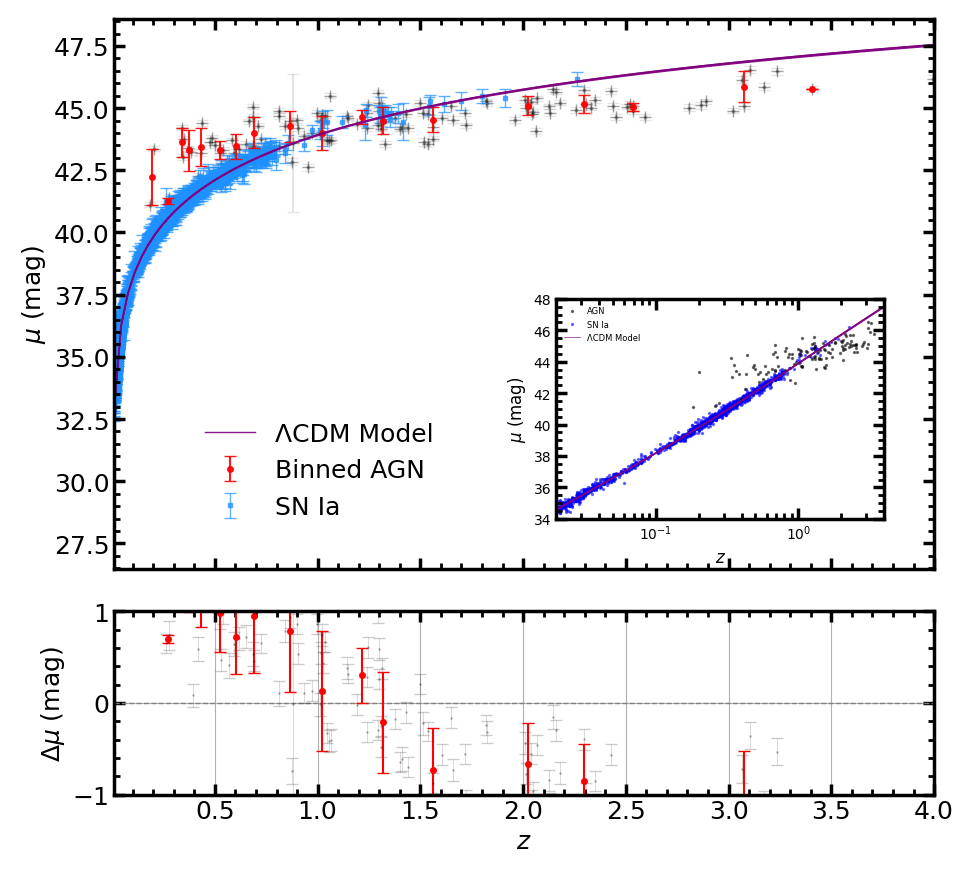

In [8]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.cm as cm
import matplotlib.colors as colors

def plot_hubble(flat_samples, filename="hubble_plot.png"):
    """Plot Hubble diagram + residuals, classic Pantheon+ style."""
    
    # --- Cosmology model ---
    z_grid = np.linspace(0.01, 4.0, len(df))
    mu_models = np.array([
        FlatLambdaCDM(H0=s[-2], Om0=s[-1]).distmod(z_grid).value for s in flat_samples
    ])
    mu_model_median = np.percentile(mu_models, 50, axis=0)
    mu_model_16th = np.percentile(mu_models, 16, axis=0)
    mu_model_84th = np.percentile(mu_models, 84, axis=0)

    # --- AGN distance modulus ---
    mu_pred = np.array([
        df['apparent_mag_i'] - M_model_single(s[2], s[0], s[1], df['log_sigma_RF'], df['log_tau_RF']) - K_corr(df["z"])
        for s in flat_samples
    ])
    mu_pred_median = np.percentile(mu_pred, 50, axis=0)
    mu_pred_16th = np.percentile(mu_pred, 16, axis=0)
    mu_pred_84th = np.percentile(mu_pred, 84, axis=0)
    mu_pred_std = np.sqrt(df['apparent_mag_i_err']**2 + np.var(mu_pred, axis=0))

    # --- Residuals ---
    mu_model_z = FlatLambdaCDM(H0=np.median(flat_samples[:, -2]), Om0=np.median(flat_samples[:, -1])).distmod(df["z"]).value
    residuals = mu_pred_median - mu_model_z

    # --- Binning ---
    bins = np.logspace(np.log10(df["z"].min()), np.log10(df["z"].max()), 20)
    bin_indices = np.digitize(df["z"], bins)
    binned_mu_pred_median = [np.median(mu_pred_median[bin_indices == i]) for i in range(1, len(bins))]
    binned_mu_pred_std = [np.std(mu_pred_median[bin_indices == i]) for i in range(1, len(bins))]
    binned_z = [np.median(df["z"][bin_indices == i]) for i in range(1, len(bins))]

    binned_residuals = [np.median(residuals[bin_indices == i]) for i in range(1, len(bins))]
    binned_residuals_std = [np.std(residuals[bin_indices == i]) for i in range(1, len(bins))]

    # --- Plot setup ---
    fig, (ax, ax_resid) = plt.subplots(2, 1, figsize=(10, 9), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
    inset_ax = inset_axes(ax, width="40%", height="40%", loc="lower right", borderpad=2)

    # --- Inset plot ---
    inset_ax.scatter(df["z"], mu_pred_median, s=2, label="AGN", alpha=0.5, color="black",zorder=-9)
    inset_ax.scatter(df_pantheon["zHD"], df_pantheon["MU_SH0ES"], color="blue", s=2, label="SN Ia", alpha=0.5, zorder=-10)
    inset_ax.plot(z_grid, mu_model_median, alpha=0.9, color="purple", zorder=-9, lw=0.5, label="ΛCDM Model")
    inset_ax.fill_between(z_grid, mu_model_16th, mu_model_84th, color="purple", alpha=0.9)
    inset_ax.set_xscale('log')
    inset_ax.set_xlim(0.02, 4.0)
    inset_ax.set_ylim(34, 48)
    inset_ax.set_xlabel(r"$z$", fontsize=12)
    inset_ax.set_ylabel(r"$\mu$ (mag)", fontsize=12)
    inset_ax.tick_params(axis='both', which='major', labelsize=10)
    inset_ax.legend(frameon=False, fontsize=6)

    # --- Main Hubble diagram ---
    # Original AGNs
    ax.errorbar(df["z"], mu_pred_median, yerr=mu_pred_std, fmt='none', linestyle='none',
                alpha=0.1, color="k", lw=1.5, zorder=-10)
    ax.errorbar(df["z"], mu_pred_median, yerr=0, xerr=0, fmt='o', markersize=2, 
                alpha=0.2, color="k", lw=1.5, zorder=-10)

    # Binned AGNs
    ax.errorbar(binned_z, binned_mu_pred_median, yerr=binned_mu_pred_std, fmt='o', markersize=4, 
                label="Binned AGN", alpha=0.9, color="red", lw=1.5, zorder=-7)

    # SNIa points
    ax.errorbar(df_pantheon["zHD"], df_pantheon["MU_SH0ES"], yerr=df_pantheon["MU_SH0ES_ERR_DIAG"], 
                fmt='s', markersize=3, color="dodgerblue", linestyle='none', lw=1, label="SN Ia", alpha=0.7, zorder=-8)

    # ΛCDM band
    ax.plot(z_grid, mu_model_median, alpha=0.9, color="purple", zorder=-5, lw=1, label="ΛCDM Model")
    ax.fill_between(z_grid, mu_model_16th, mu_model_84th, color="purple", alpha=0.9, zorder=-5)

    ax.set_ylabel(r"$\mu$ (mag)")
    #ax.set_xscale('log')
    ax.set_xlim(0.01, 4.0)
    #ax.set_ylim(32, 48)
    ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.25, 0.05))

    # --- Residuals plot ---
    ax_resid.axhline(0, color='gray', linestyle='--', lw=1)
    # Individual AGN residuals
    ax_resid.errorbar(df["z"], residuals, yerr=mu_pred_std, fmt='.', alpha=0.2, color="black", lw=0.5, markersize=2)
    # Binned residuals
    ax_resid.errorbar(binned_z, binned_residuals, yerr=binned_residuals_std, fmt='o', color="red", markersize=4, lw=1.5)

    ax_resid.set_xlabel(r"$z$")
    ax_resid.set_ylabel(r"$\Delta \mu$ (mag)")
    #ax_resid.set_xscale('log')
    ax_resid.set_xlim(0.01, 4.0)
    ax_resid.set_ylim(-1, 1)
    ax_resid.grid(True)

    # Ticks styling
    for axi in [ax, ax_resid, inset_ax]:
        axi.minorticks_on()
        axi.tick_params(axis='both', which='minor', direction='in', length=4, top=True, right=True, width=2)
        axi.tick_params(axis='both', which='major', direction='in', length=8, top=True, right=True)

    fig.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()
    plt.close()

plot_hubble(flat_samples, filename="hubble_plot.png")

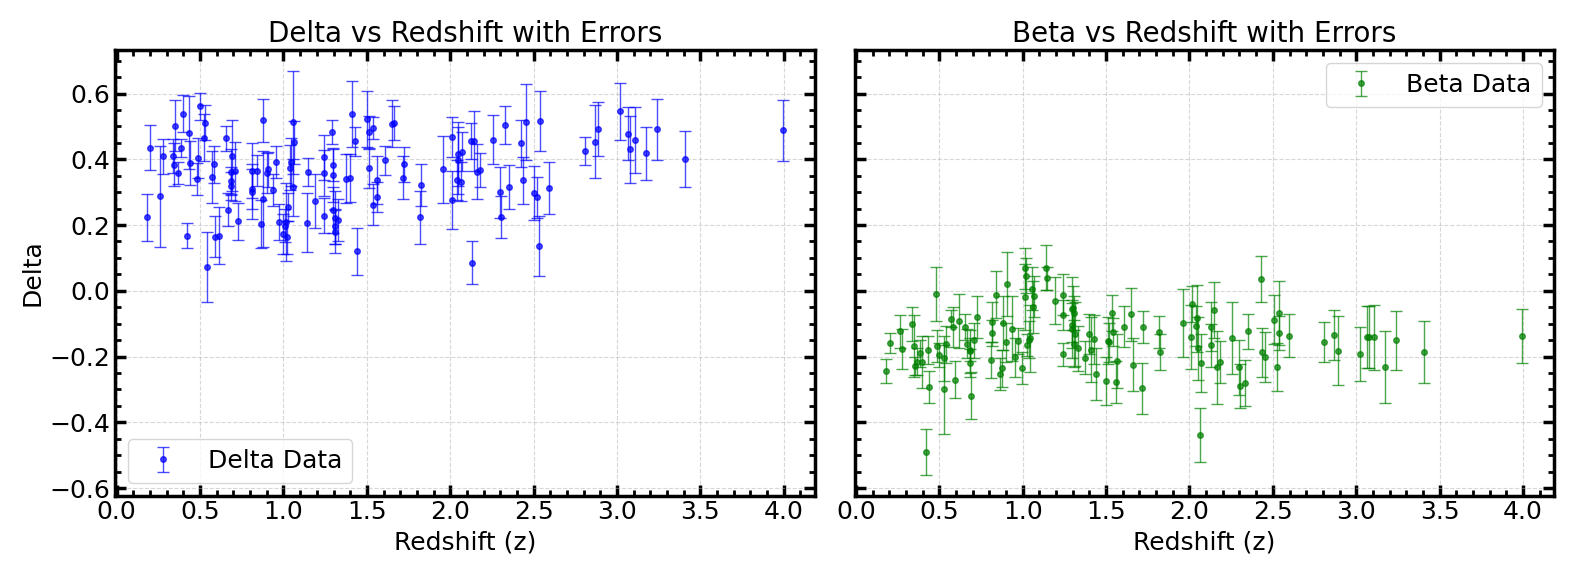

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Left subfigure: Delta vs Redshift
axes[0].errorbar(df['z'], df['delta'], yerr=df['delta_err'], fmt='o', markersize=4, alpha=0.7, label='Delta Data', color='blue', lw=1)
axes[0].set_xlabel('Redshift (z)')
axes[0].set_ylabel('Delta')
axes[0].set_title('Delta vs Redshift with Errors')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

# Right subfigure: Beta vs Redshift
axes[1].errorbar(df['z'], df['beta'], yerr=df['beta_err'], fmt='o', markersize=4, alpha=0.7, label='Beta Data', color='green', lw=1)
axes[1].set_xlabel('Redshift (z)')
axes[1].set_title('Beta vs Redshift with Errors')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()